In [1]:
%reload_ext autoreload
%autoreload 2

In [3]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx

from probjax.nn import GaussianFourierEmbedding
from probjax.nn.nets.flow_matching_model import RectifiedFlow


In [4]:
def generate_data(key):
    # Mixture of Gaussians
    key, subkey = jax.random.split(key)
    u = jax.random.uniform(subkey)
    eps = jax.random.normal(subkey, (2,))*0.5
    x = jnp.where(u < 0.5, eps[0]-3., eps[1]+3)
    return x[None]

[3.21]


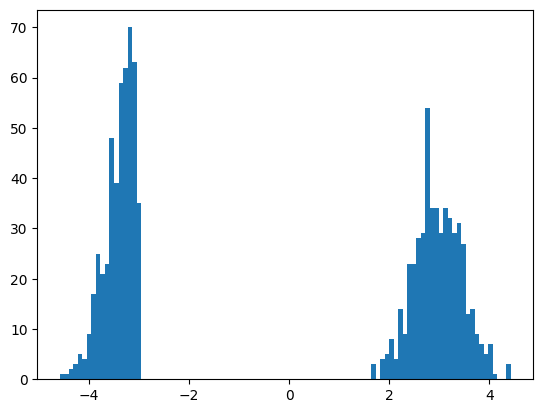

In [5]:
xs = jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 1000))
print(xs.std(0))
_ = plt.hist(xs.flatten(), bins=100)

In [7]:
from probjax.nn.nets.simple import ResNet

d = 1
class BaseModel(nnx.Module, experimental_pytree=True):
    def __init__(self, d, rngs, time_embed_dim=8) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,time_embed_dim, rngs=rngs)
        #self.time_embedding = lambda t: jnp.repeat(t, 5, axis=-1)
        self.resnet = ResNet(d,d,rngs,context_dim=time_embed_dim, num_hidden_layers=3, norm=nnx.LayerNorm)

    def __call__(self, t,x, *args, **kwargs):
        time_embed = self.time_embedding(t)
        output = self.resnet(x, context=time_embed)
        return output

net = BaseModel(1, nnx.Rngs(0))
model = RectifiedFlow(net,std0=1., std1=1.)
params = nnx.state(model, nnx.Param)

In [8]:
model(jnp.ones((1,)) * 0.1, jnp.ones((1,)))

Array([0.171], dtype=float32)

In [21]:

import optax

opt = optax.chain(optax.adaptive_grad_clip(10.), optax.ema(0.001), optax.adamw(5e-4))
opt_state = opt.init(params)

def loss_fn(params, rng, x):
    nnx.update(model, params)
    return model.loss(rng, x)

@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng,x)
    updates, opt_state = opt.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [22]:
key = jax.random.key(0)

In [23]:
losses = []
for i in range(600):
    l = 0.
    for j in range(10):
        key,key_data, key_loss = jax.random.split(key, 3)
        xs = jax.vmap(generate_data)(jax.random.split(key_data, 1000))
        params, opt_state, loss = update(params, opt_state, xs,key_loss)
        l += loss
    losses.append(l/10)

KeyboardInterrupt: 

In [24]:
nnx.update(model, params)

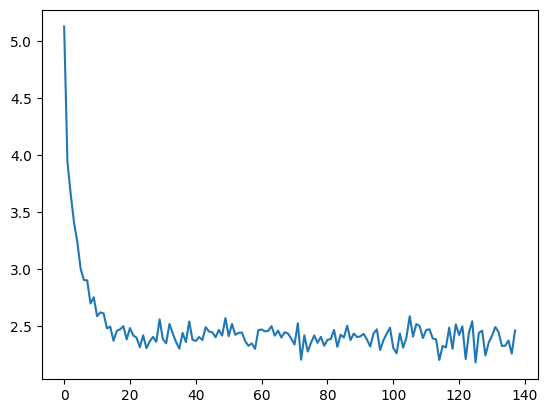

In [25]:
plt.plot(losses)

In [26]:
from probjax.utils.odeint import odeint


def sample(rng):
    eps = jax.random.normal(rng, (d,)) * model.std0.value + model.mu0.value
    ts = model.solve_schedule(50)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        v = model(t, x) # Why is this negative?
        return v.reshape(x.shape)

    return odeint(drift, eps,ts, method="euler")


In [27]:
keys = jax.random.split(key, (10_000,))
xs = jax.vmap(sample)(keys)

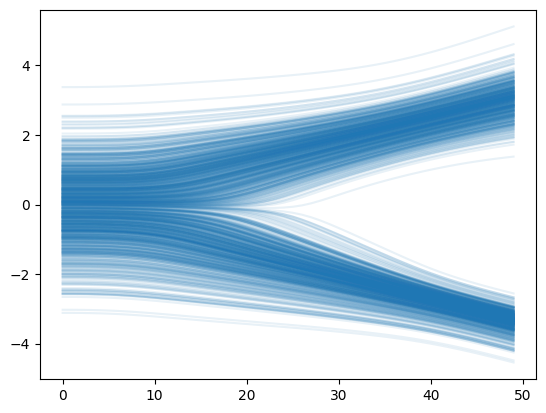

In [28]:
_ = plt.plot(xs[::10,:,0].T, color="C0", alpha=0.1)
#plt.ylim(-10,10)

(-7.0, 7.0)

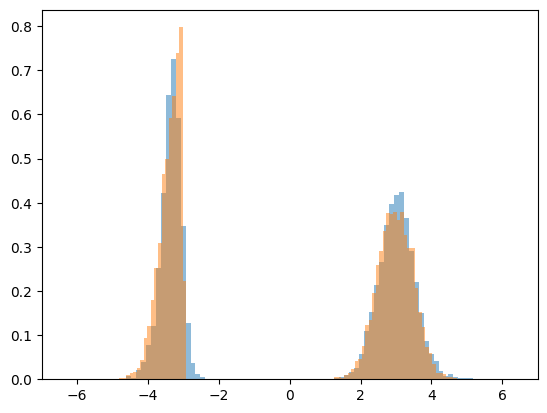

In [29]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True, range=(-7,7), alpha=0.5)
_ = plt.hist(jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 10000)).flatten(), bins=100, density=True, alpha=0.5)

plt.xlim(-7,7)

In [74]:
from probjax.utils.sdeint import sdeint

# Stochastic sampling

def sample(rng):
    rng_init, rng_solve = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (d,)) * model.std0.value + model.mu0.value
    ts = model.solve_schedule(500)

    # One cannot add too much noise, as network was trained without!
    def diffusion(t, x):
        g = jnp.sqrt((1-t)*t) * 0.3
        return g* jnp.ones_like(x)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        v = model(t, x)
        s = model.score(t, x, max_t=0.99)
        g = diffusion(t, x)
        return v + 0.5*g**2 * s

    return sdeint(rng_solve, drift, diffusion, eps,ts, method="euler_maruyama")


In [75]:
keys = jax.random.split(key, (10_000,))
xs = jax.vmap(sample)(keys)

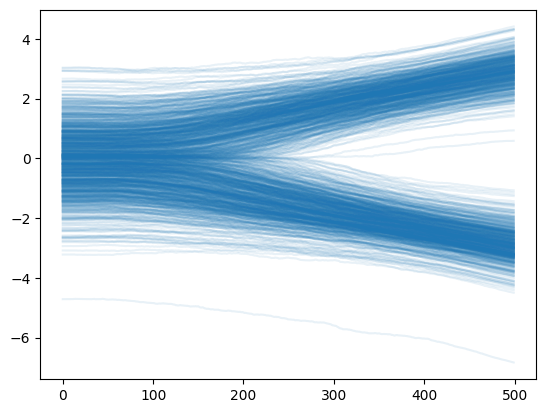

In [76]:
_ = plt.plot(xs[::10,:,0].T, color="C0", alpha=0.1)
#plt.ylim(-10,10)

(-7.0, 7.0)

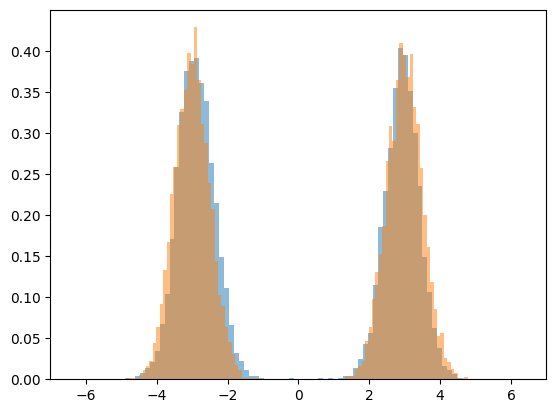

In [77]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True, range=(-7,7), alpha=0.5)
_ = plt.hist(jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 10000)).flatten(), bins=100, density=True, alpha=0.5)

plt.xlim(-7,7)

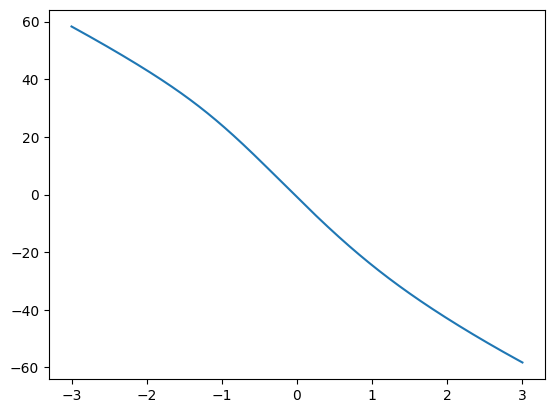

In [67]:
xs = jnp.linspace(-3,3,1000)
score = model.score(jnp.ones((1000,1))*0.9, xs[:,None])

plt.plot(xs, score.flatten())